## Day 4 - Demo 1

Two silent-break examples with plausible but wrong behavior.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### 1a. Boxplot

You have a numeric measurements from three different conditions, both sexes.

You want to visualize it in a boxplot. What's wrong with this code?

In [192]:
def plot_boxplot(data, x, y, fill, figsize=(10,6)):
    figure, ax = plt.subplots(figsize=figsize)
    
    sns.boxplot(data=data, x=x, y=y, 
                hue=fill, flierprops={'markerfacecolor': 'black'}, ax=ax)
    sns.stripplot(data=data, x=x, y=y, 
                  hue=fill, dodge=True, palette='dark:black', size = 6, legend=False, ax=ax)
    
    plt.close(figure)
    return figure

Here are some helper functions to generate mock data.

In [193]:
def generate_mock_data(num_samples=500, seed=None):
    np.random.seed(seed)
    data = pd.DataFrame({
        'Sample_ID': [f'Sample_{i}' for i in range(1, num_samples + 1)],
        'Condition': np.random.choice(['A', 'B', 'C'], size=num_samples),
        'Sex': np.random.choice(['Male', 'Female'], size=num_samples),
        'Measurement': np.random.normal(loc=0, scale=1, size=num_samples)
    })
    return data


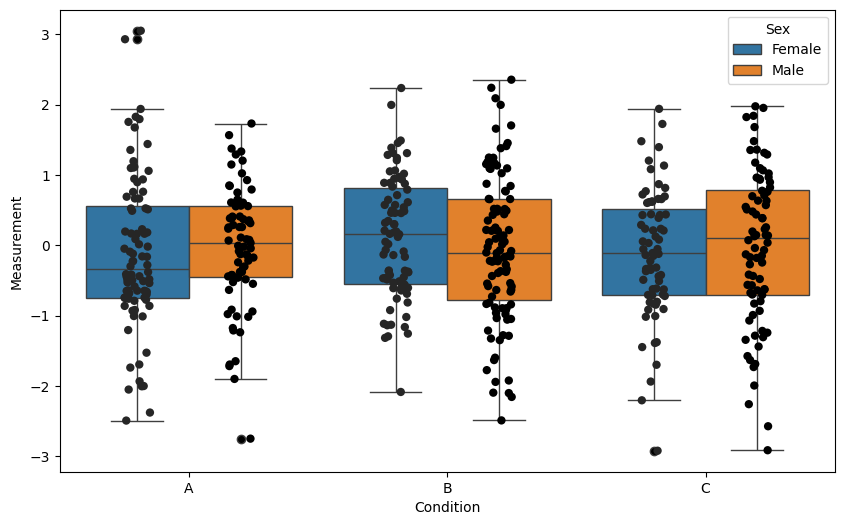

In [194]:
demo1a_mock_data = generate_mock_data(num_samples=500)
plot_boxplot(demo1a_mock_data, x='Condition', y='Measurement', fill='Sex')

#### 1b. Moving average

I have a noisy time-series data for many individuals. Each row is a sample, each column is the minute from which the measurement was recorded.
Because the data is quite noisy, I smooth the data using a moving average. THen I plot the trend overtime for each group.

What can potentially be wrong with the code

In [210]:
def plot_smoothed_measurements(data, window=5, figsize=(10,6)):
    """
    Plot smoothed time-series data by condition (color) and sex (style).

    Parameters
    ----------
    data : pandas.DataFrame
        Contains 'Condition', 'Sex', and numeric time columns (e.g., '1','2',...).
    window : int, default=5
        Rolling window for smoothing across time (columns).
    figsize : tuple, default=(10, 6)
        Figure size.

    Returns
    -------
    matplotlib.figure.Figure
        The plot of time-smoothed measurements.
    """
    smoothed_data = data.copy()
    # Identify columns containing time-series measurement (e.g., '1', '2', ...)
    measurement_cols = [col for col in data.columns if str(col).isdigit()]

    # Smooth across time for each sample
    smoothed_data[measurement_cols] = smoothed_data[measurement_cols].rolling(window=window, min_periods=1, center=True).mean()

    # Convert to long format
    long_df = smoothed_data.melt(
        id_vars=['Condition', 'Sex'], 
        value_vars=measurement_cols, 
        var_name='Time', 
        value_name='Value'
    )
    long_df['Time'] = long_df['Time'].astype(int)

    # Plot: color by condition, line style by sex
    figure, ax = plt.subplots(figsize=figsize)
    sns.lineplot(data=long_df, x='Time', y='Value', hue='Condition', style='Sex', errorbar=None, ax=ax)
    ax.set_title('Smoothed Measurements')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    
    plt.close()

    return figure

Here is the helper function to generate mock data and test the function

In [211]:
def generate_mock_time_series(num_samples=80, num_timepoints=90, seed=None):
    rng = np.random.default_rng(seed)

    # Time series data with explicit column names
    time_cols = [str(i) for i in range(num_timepoints)]
    time_series_data = pd.DataFrame(
        rng.random((num_samples, num_timepoints)),
        columns=time_cols
    )

    # Metadata
    metadata = pd.DataFrame({
        'Sample_ID': [f'Sample_{i}' for i in range(1, num_samples + 1)],
        'Condition': rng.choice(['A', 'B'], size=num_samples),
        'Sex': rng.choice(['Male', 'Female'], size=num_samples),
    })

    data = pd.concat([metadata, time_series_data], axis=1)

    return data

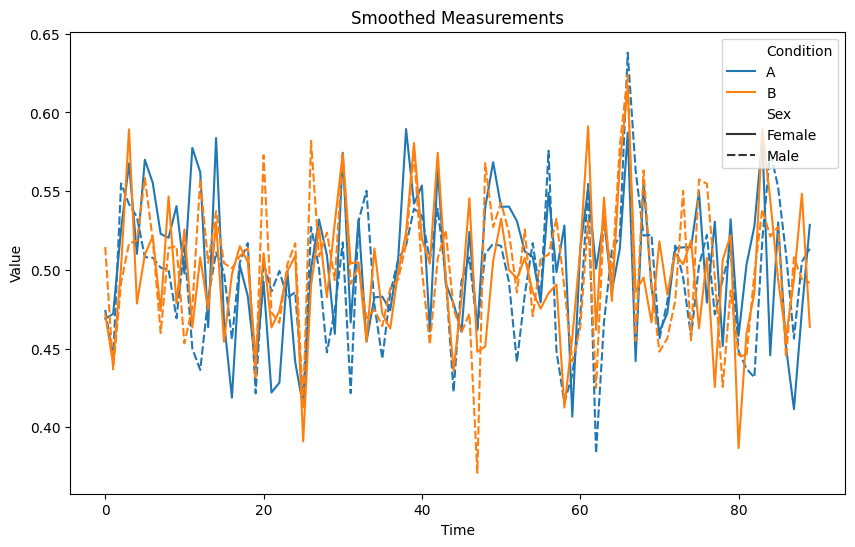

In [ ]:
demo1b_mock_data = generate_mock_time_series()
plot_smoothed_measurements(demo1b_mock_data, window=5)